# Seminar 1. Bayesian Machine learning. Use cases

In [2]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats as sps
import matplotlib.pyplot as plt
from IPython.display import clear_output

%matplotlib inline

# A simple example of the Bayesian inference
Let us have a dataset $\mathcal{D} = \{x_i\}_{i=1}^n$ of iid samples from normal distribution with unknown mean $\theta$:  $x\sim \mathcal{N}(x|\theta,\sigma^{2})$.  
In bayesian approach, we can define a prior distribution for the unknown mean: $\theta \sim p(\theta)$.  
We want to derive two distributions describing the data: 
1. The posterior desribution $p(\theta|\mathcal{D})$ of the mean $\theta$ given the observed data $\mathcal{D}$ 
2. The distribution of random variable $x$, $p(x|\mathcal{D})$, given the observed data $\mathcal{D}$.

In our experiment we will use a column, `Alcalinity of ash`, of the dataset <a href="http://archive.ics.uci.edu/ml/datasets/Wine"> about wine</a> as $\mathcal{D}$. 

###  1. Posterior distribution of the parameter $\theta$

In accordance with Bayes formula, we can calculate posterior distribution:

$$p(\theta|\mathcal{D}) = \frac{p(\mathcal{D}|\theta)p(\theta)}{p(\mathcal{D})} = \frac{p(\theta)\prod_{i=1}^n p(x_i|\theta)}{\int\limits_\Theta p(\theta)\prod_{i=1}^n p(x_i|\theta) d\theta}$$
where $p(x|\theta)$ is the density of the distribution $\mathcal{N}(x|\theta,\sigma^{2})$; $p(\theta)$ is the density of the standard Cauchy distribution in our example; $p(\mathcal{D})$ is the *evidence*. 

<!-- Let the prior $p(\theta)$ distribution for $\theta$ be the standard Cauchy distribution. Then, i -->


### 2. Distribution of the random variable $x$
In fully bayesian approach we marginalize parameter $\theta$ in order to get distribution of $x$ conditional on the observed data:

$$
p(x|\mathcal{D})=\int_{\mathbb{R}}p(x|\theta)p(\theta|\mathcal{D})d\theta
$$

to calculate $p(\theta|\mathcal{D})$ we need to compute evidence $p(\mathcal{D})$.  
In general, we can not compute it analiticaly, and here we resort to Monte-Carlo methods.  
We approximate posterior with empirical distribution

$$
\begin{equation}
    q(\theta) = \frac{1}{N}\sum_{i=1}^N\delta (\theta - \theta_i),\quad \theta_i \sim p(\theta|\mathcal{D})
\end{equation}
$$
If number of points $N$ is sufficienly big, we can assume that $q(\theta)\approx p(\theta|\mathcal{D})$ and 

$$
\begin{equation}
    p(x|\mathcal{D}) = \int_{\mathbb{R}} p(x|\theta) p(\theta|\mathcal{D})d\theta \approx \int p(x|\theta)q(\theta)d\theta = \frac{1}{N}\sum_{i=1}^Np(x|\theta_i)
\end{equation}
$$

Samples from unnormalized posterior $p(\theta|\mathcal{D})\propto p(\mathcal{D}|\theta)p(\theta)$ can be obtained using Metropolis-Hastings algorithm.

In [3]:
wine_frame = pd.read_csv("data/wine.data", header=None)
data = wine_frame[4].values
sigma = 3.0  # known observation noise

In [4]:
def log_unnormalized_posterior(theta, data, sigma, prior_loc=0.0, prior_scale=1.0):
    """
    Log of p(theta | data) ∝ p(data | theta) * p(theta)
    We work in log-space for numerical stability.
    """
    # Log-prior: theta ~ Cauchy(prior_loc, prior_scale)
    log_prior = sps.cauchy.logpdf(theta, loc=prior_loc, scale=prior_scale)

    # Log-likelihood: data ~ Normal(theta, sigma^2)
    log_likelihood = np.sum(sps.norm.logpdf(data, loc=theta, scale=sigma))

    return log_prior + log_likelihood

Acceptance rate: 62.54%


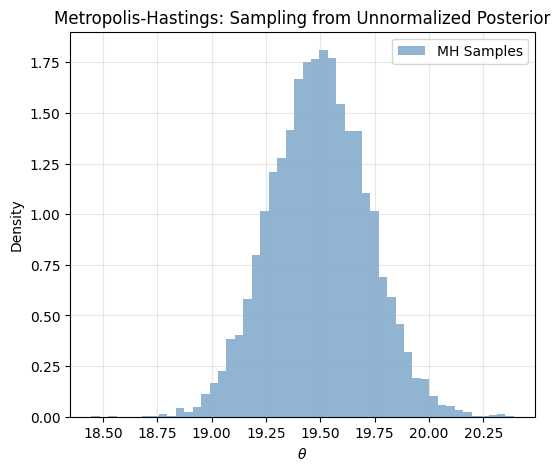

MH sample mean: 19.495
MH sample std:  0.222


In [5]:
# Metropolis-Hastings sampler
def metropolis_hastings(
    log_posterior,
    data,
    sigma,
    proposal_std=0.5,
    n_samples=10000,
    initial_theta=0.0,
    random_seed=42,
):
    """
    Basic Metropolis-Hastings for 1D parameter theta.
    Uses a symmetric Gaussian proposal: q(theta_new | theta_old) = N(theta_old, proposal_std^2)
    """
    np.random.seed(random_seed)
    samples = np.zeros(n_samples)
    current_theta = initial_theta
    current_log_prob = log_posterior(current_theta, data, sigma)

    accept_count = 0

    for i in range(n_samples):
        # Propose new theta
        proposed_theta = np.random.normal(current_theta, proposal_std)

        # Compute log posterior for proposed theta
        proposed_log_prob = log_posterior(proposed_theta, data, sigma)

        # Compute acceptance ratio (in log space)
        log_alpha = proposed_log_prob - current_log_prob

        # Accept or reject
        if np.log(np.random.rand()) < log_alpha:
            current_theta = proposed_theta
            current_log_prob = proposed_log_prob
            accept_count += 1

        samples[i] = current_theta

    acceptance_rate = accept_count / n_samples
    print(f"Acceptance rate: {acceptance_rate:.2%}")
    return samples


posterior_theta_samples = metropolis_hastings(
    log_unnormalized_posterior,
    data=data,
    sigma=sigma,
    proposal_std=0.3,  # Tune for ~20-50% acceptance
    n_samples=20000,
    initial_theta=0.0,
)

# Discard burn-in (first 20%)
burn_in = 4000
posterior_theta_samples = posterior_theta_samples[burn_in:]

plt.figure(figsize=(6, 5))

# Histogram of MH samples
plt.hist(
    posterior_theta_samples,
    bins=50,
    density=True,
    alpha=0.6,
    color="steelblue",
    label="MH Samples",
)

# Add labels
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.title("Metropolis-Hastings: Sampling from Unnormalized Posterior")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print summary
print(f"MH sample mean: {np.mean(posterior_theta_samples):.3f}")
print(f"MH sample std:  {np.std(posterior_theta_samples):.3f}")

### compute $p(x|\mathcal{D})$

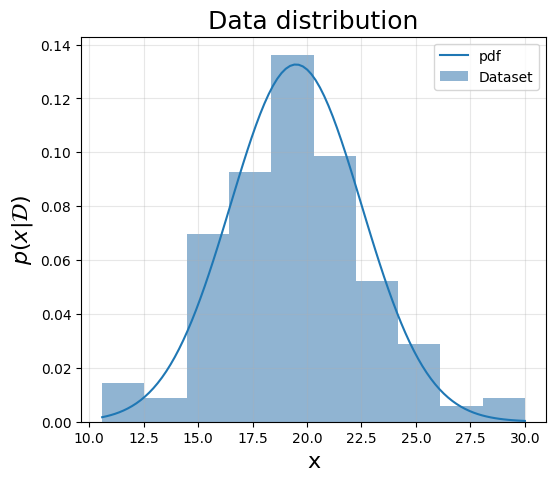

In [6]:
x_test = np.linspace(data.min(), data.max(), num=100)
posterior_x_density = np.mean(
    sps.norm.pdf(x_test[:, None], loc=posterior_theta_samples, scale=sigma), axis=1
)

plt.figure(figsize=(6, 5))
plt.plot(x_test, posterior_x_density, label="pdf")
plt.hist(data, bins=10, density=True, alpha=0.6, color="steelblue", label="Dataset")
plt.title("Data distribution", fontsize=18)
plt.xlabel("x", fontsize=16)
plt.ylabel("$p(x|\mathcal{D})$", fontsize=16)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Approximate $p(\mathcal{D})$ and compute $p(\theta|\mathcal{D})$ directely

In [7]:
theta_test = np.linspace(19.58 - 1, 19.58 + 1, num=100)
prior_theta_samples = sps.cauchy.rvs(loc=0, scale=1, size=100000)
log_evidence = np.log(
    np.mean(
        np.product(
            sps.norm.pdf(data[:, None], loc=prior_theta_samples, scale=sigma), axis=0
        )
    )
)

In [8]:
log_evidence

-476.46107652135026

In [9]:
log_theta_posterior = (
    sps.cauchy.logpdf(theta_test)
    + np.sum(sps.norm.logpdf(data[:, None], loc=theta_test, scale=sigma), axis=0)
    - log_evidence
)

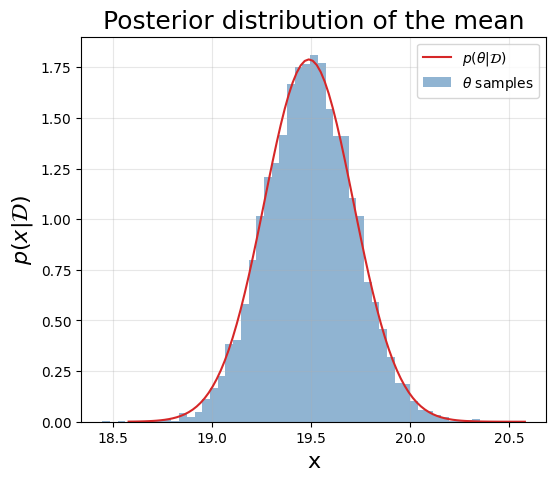

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(
    theta_test,
    np.exp(log_theta_posterior),
    label="$p(\\theta|\mathcal{D})$",
    c="tab:red",
)
plt.hist(
    posterior_theta_samples,
    bins=50,
    density=True,
    alpha=0.6,
    color="steelblue",
    label="$\\theta$ samples",
)
plt.title("Posterior distribution of the mean", fontsize=18)
plt.xlabel("x", fontsize=16)
plt.ylabel("$p(\\theta|\mathcal{D})$", fontsize=16)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

It is worth noticing, that error of the monte-Carlo sampling $\approx O(\frac{1}{\sqrt n})$
As a consequelntly of this,  in order to get result more precise in  $k$ times, you should have samples in $k^2$ times more.

### task: perform model selection on the parameter $\sigma^2$

In [1]:
# your code is here

## 2. Conjugate Distributions

### 2.1 Task of finding posterior distribution.

Derive posterior for parameter $p$, in coin toss experiment while $\text{Beta}(\alpha_0,\beta_0)$ is prior for $p$. The PDF for the Beta distribution is
$$
\begin{align}
f(p|\alpha,\beta) & = \frac{p^{\alpha-1}(1-p)^{\beta-1}}{\displaystyle \int_0^1 u^{\alpha-1} (1-u)^{\beta-1}\, du} = C p^{\alpha-1}(1-p)^{\beta-1}
\end{align} 
$$

In [2]:
# At the seminar derive posterior

### 2.2 Task

Consider Bernoulli scheme (coin toss) with the probability of success $p$. Plot some plots of conjugate  prior distribution for different paramters and explain how values of these parameters of the prior distribution correspond with prior knowledge of coin. For example:
- the knowledge is  "coin is most likely honest" , then more probable values of $p$  are located near 0.5
- the knowledge is " coin is not most likely honest  (tail)", then more probable values of $p$  are located near 1
- the knowledge is "coin is not  honest",  then less probable values of $p$  are located near 0.5
- the knowledge is " coin is not most likely honest  (head)", then more probable values of $p$  are located near 0
- the knowledge is "we have no information about the value of probability $p$" , then we have the uniform prior on $p$

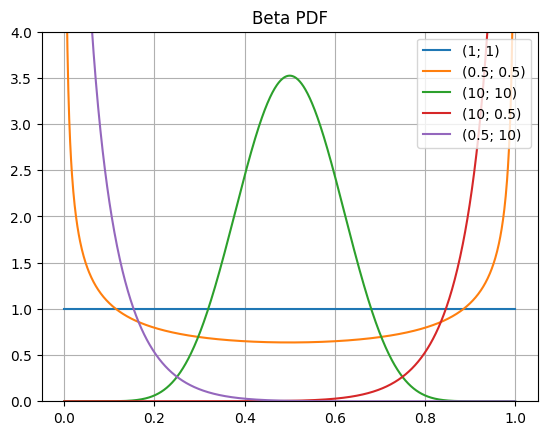

In [49]:
params = [[1, 1], [0.5, 0.5], [10, 10], [10, 0.5], [0.5, 10]]
x = np.linspace(0, 1, 10**3)
fig = plt.figure(1)
ax = fig.add_subplot(111)
ax.set_title("Beta PDF")
for k in range(len(params)):
    beta_d = sps.beta(params[k][0], params[k][1])
    bet = []
    for i in range(len(x)):
        bet.append(beta_d.pdf(x[i]))
    ax.plot(x, bet, label="(" + str(params[k][0]) + "; " + str(params[k][1]) + ")")
ax.set_ylim([0, 4])
ax.grid(True)
ax.legend(loc="best")

- In according to plots  of prior Beta distributions, we see that statement "coin is most likely honest"  correspond equal values of parameters of prior distributions, that are more than 1.  

- statement "coin is not  honest" corresponds equal values of parameters that are. less than 1.

- statement  " coin is not most likely honest  (tail)"  corresponds high values of the 1st parameter and low for the 2nd.  $\beta$(ideally- --- $\alpha > 1; \beta \leqslant 1$)

-  statement  " coin is not most likely honest  (head)"  corresponds low values of the 1st parameter and high for the 2nd. $\beta$(ideally- --- $\alpha < 1; \beta \geqslant 1$)
 - statement "we have no information about the value of probability $p$" corresponds to $\beta = \alpha = 1$

Let's do an experiment with a coin.

Based on the seminar from Dmitry Vetrov course ([link](http://www.machinelearning.ru/wiki/index.php?title=%D0%91%D0%BC%D0%BC%D0%BE))


In [11]:
class Coin:
    def __init__(self):
        self.p = np.random.uniform(0, 1.0)

    def sample(self):
        return np.random.choice([1, 0], p=[self.p, 1 - self.p])

In [12]:
prob_beta = (
    lambda x, a, b: 1 / scipy.special.beta(a, b) * x ** (a - 1) * (1 - x) ** (b - 1)
)

In [13]:
def get_posterior(values, a, b):
    a_post = a + np.sum(values)
    b_post = b + len(values) - np.sum(values)
    return a_post, b_post

In [14]:
coin = Coin()
print(coin.p)

0.193463571522846


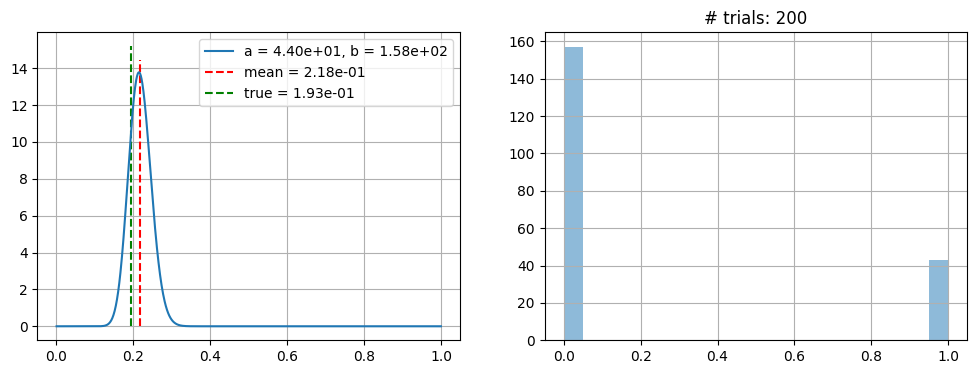

In [16]:
values = []
a = 1
b = 1
for idx in range(200):
    clear_output(True)
    plt.figure(figsize=(12, 4))
    sample = coin.sample()
    values.append(sample)
    a, b = get_posterior([sample], a, b)
    # a, b = get_posterior(values, a, b)
    plt.subplot(1, 2, 1)
    x = np.linspace(0.001, 0.999, 1000)
    plt.plot(x, prob_beta(x, a, b), label="a = {0:.2e}, b = {1:.2e}".format(a, b))
    p_bayes = a / (b + a)
    plt.vlines(
        p_bayes,
        0,
        plt.gca().get_ylim()[1],
        linestyle="--",
        label="mean = {0:.2e}".format(p_bayes),
        color="r",
    )
    plt.vlines(
        coin.p,
        0,
        plt.gca().get_ylim()[1],
        linestyle="--",
        label="true = {0:.2e}".format(coin.p),
        color="g",
    )
    plt.grid(True)
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.hist(values, bins=20, alpha=0.5)
    x = np.linspace(0.01, 1000, 2000)
    plt.grid(True)
    plt.title("# trials: {}".format(len(values)))
    plt.show()